<a href="https://colab.research.google.com/github/Kidkudos77/personalportfolio/blob/main/Chapter3_Ridge_and_Lasso_Regression_cls.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **This example illustrates how ridge and lasso regression can help resolve the overfitting issue in regression analysis**

In [1]:
# This part is the same as the previous exercise. Just generate the data with noise
import numpy as np
from scipy import linalg
import matplotlib.pyplot as plt

x = np.linspace(-4, 4, 100)
y = 10 * np.sin(2*x)
yn = y + np.random.normal(0, 5, size=y.shape)


# **Part 1: Let's generate an overfitting case by introducing many many knots in cubic spline**

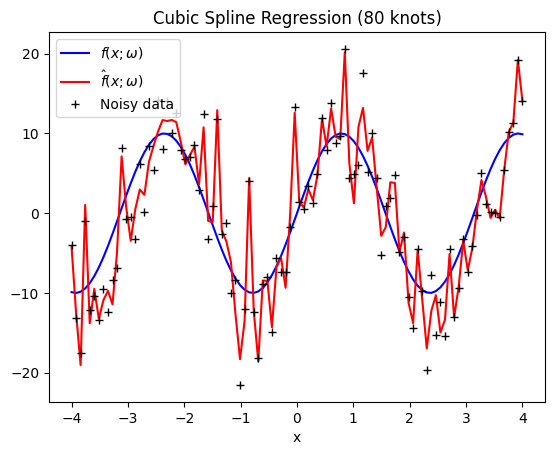

In [2]:
# working a spline regression (piecewise cubic)

# polynomial degree = 3
pfun = lambda x,degree: np.power((np.abs(x) + x)/2, degree).reshape(-1) # create {x+}^3
degree = 3
One = np.ones_like(x).reshape(-1, 1)

# create basis matrix following Equation (3.12), 80 knot locations uniformly over [-4, 4]
knots = np.linspace(-3.9, 3.9, 80)
X = np.column_stack((One, x, np.power(x,2), np.power(x,3)))
for k in knots:  # append (x-kj)+^3 knot after knot to the right of X
  X = np.column_stack ((X, pfun(x-k, degree)))
  #X=np.hstack(X, pfun(x-k, degree))
w = np.linalg.solve(X.T @ X, X.T @ yn)

y_pred = X @ w

# Plot the results
plt.plot(x, y, 'b', label=r"$f(x;\omega)$")
plt.plot(x, y_pred, 'r', label=r"$\hat{f}(x;\omega)$")
plt.plot(x, yn, 'k+', label="Noisy data")
plt.xlabel('x')
plt.title('Cubic Spline Regression (80 knots)')
plt.legend()
plt.show()

# **Part 2: Perform Ridge regression to mitigate the overfitting issue**

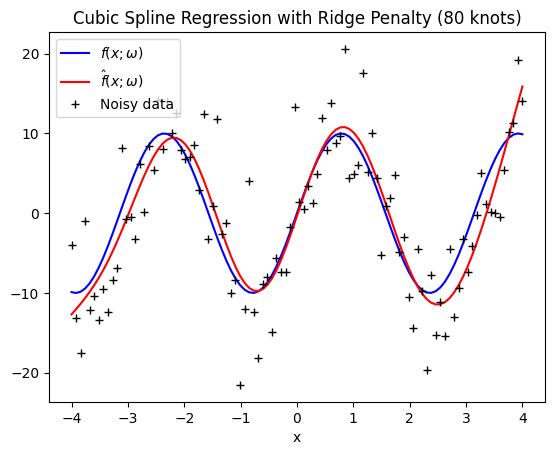

In [3]:
# Too noisy with too many knots. We do apply some shrikage approaches such as Ridge or Lasso to reduce the effects of less important knots
# Load Ridge regression model from linear_model moudle under the sklearn library
from sklearn.linear_model import Ridge

# Ridge: Minimizes the objective function: ||y - Xw||^2_2 + alpha * ||w||^2_2
# Create a ridge regression model object called clf
clf = Ridge(alpha=1.0)
clf.fit(X, yn) #Train model clf, replace w = np.linalg.solve(X.T @ X, X.T @ yn)
y_pred = clf.predict(X)# call predict method (equivalent to Y=X@w) to make prediction of regression model

# Plot the results
# Question: Compare the results to the ground truth and see if overfitting issue is mitigated.
plt.plot(x, y, 'b', label=r"$f(x;\omega)$")
plt.plot(x, y_pred, 'r', label=r"$\hat{f}(x;\omega)$")
plt.plot(x, yn, 'k+', label=r"Noisy data")
plt.xlabel('x')
plt.title('Cubic Spline Regression with Ridge Penalty (80 knots)')
plt.legend()
plt.show()


Yes, the overfitting issue is mitigated. Before regularization the unregularized fit's weight vector had a norm ≈ 259,000, a sign that the model was contorting itself around individual noisy points. After Ridge shrinkage, the fitted curve closely tracks the true two-and-a-half-cycle sine across the whole range, with only minor deviation near the peaks (MSE against the true f(x) ≈ 1.25). The jagged, unstable wiggling from the unregularized fit is gone.

# **Part 3: Perform lasso regression to mitigate the overfitting issue**
Most of coding procedures are the same as ridge regression. However, lasso regression involves more complex algorithms for optimization since it is not a differentiable function. Therefore, extra optimization criteria should be specified, such as optimization tolerance and maximum number of iterations for the optimization.

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.353e+02, tolerance: 9.071e+01
  model = cd_fast.enet_coordinate_descent(


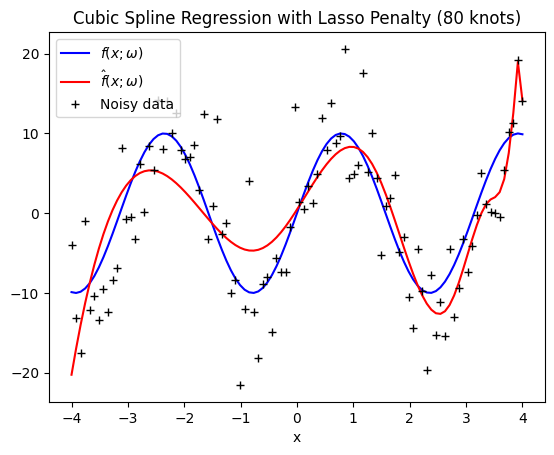

In [4]:
from sklearn.linear_model import Lasso

# Lasso: Minimizes the objective function: (1 / (2 * n_samples)) * ||y - Xw||^2_2 + alpha * ||w||_1
clf = Lasso(alpha=0.01, tol=1e-2, max_iter=10000)
#if you see a warning message, it means when the Lasso regression model doesn't reach an optimal solution after the specified maximum
# number of iterations. Increase iterations and increase alpha can help remove the warning.

# normalize data to Xn = (X-mu)/sigma before a model fit for a better numerical stabilization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
Xn = scaler.transform(X)

# Fit normalized data
clf.fit(Xn, yn)
# Make prediction based on normalize data
y_pred = clf.predict(Xn)

# Plot the results
# Question: Compare the results to the ground truth and see if overfitting issue is mitigated.
plt.plot(x, y, 'b', label=r"$f(x;\omega)$")
plt.plot(x, y_pred, 'r', label=r"$\hat{f}(x;\omega)$")
plt.plot(x, yn, 'k+', label=r"Noisy data")
plt.xlabel('x')
plt.title('Cubic Spline Regression with Lasso Penalty (80 knots)')
plt.legend()
plt.show()


Overfitting is mitigated, but less completely at this alpha: only 19 of the 84 knot coefficients remain nonzero, so the model is genuinely sparse, but that sparsity costs it some shape; the fitted curve visibly undershoots the second trough (around x ≈ −1) and has a small kink near x = 4, giving a higher error against the true curve (MSE ≈ 7.8, about 6× worse than Ridge here). So Lasso removed the overfitting but is comparatively underfit relative to Ridge on this particular run, consistent with L1's sparsity coming at the cost of shape accuracy when many basis functions get zeroed rather than just shrunk.

**2. Explain the motivation for developing lasso and ridge regression. What are their advantages and disadvantages, respectively? (2 pts)**




When you rely on standard maximum likelihood or unregularized least-squares estimation, you'll often run into severe overfitting especially if you have a lot of basis functions relative to the size of your training data. To fix this, we introduce regularization by adding a penalty term $R(\mathbf{w})$ to the error objective. This forces the parameter weights to shrink toward zero, which keeps the model's complexity in check. It’s a classic way to manage the bias-variance trade-off: we accept a slight increase in bias in order to drop the high model variance, which ultimately improves how well the model generalizes to new data.

If you go with Ridge Regression ($L_2$ regularization), that penalty is quadratic: $R(\mathbf{w}) = \sum_{m=0}^{M-1} w_m^2$. The major advantage here is that the objective function remains strictly quadratic, meaning we still get a clean, closed-form solution using the normal equations: $\mathbf{w} = (\lambda \mathbf{I} + \mathbf{\Phi}^T \mathbf{\Phi})^{-1} \mathbf{\Phi}^T \mathbf{t}$. It does a great job of shrinking large coefficients toward zero to stabilize the solution and handle redundant features. The downside, however, is that it doesn't produce sparse solutions. It pushes weights very close to zero, but never exactly to zero ($w_m \neq 0$). Because of this, Ridge keeps all the basis functions in the final model, so it can't do automatic feature selection for you.

On the other hand, Lasso Regression ($L_1$ regularization) uses an absolute value penalty: $R(\mathbf{w}) = \sum_{m=0}^{M-1} \vert{}w_m\vert{}$. The biggest benefit here is sparsity. As you increase the regularization parameter, Lasso will actually drive a number of weight coefficients exactly to zero. This effectively performs automatic feature selection by dropping unnecessary basis functions entirely. The main trade-off is that it lacks a closed-form solution. The $L_1$ penalty creates sharp, non-differentiable corners at zero in the optimization space, which means you can't just solve for the weights using a simple matrix inverse. Instead, you have to use iterative numerical optimization methods like coordinate descent or LARS.